# Stage 2: Attribute Extraction

This notebook covers extracting visual attributes from garment images, focusing on color extraction.

**Objectives:**
- Extract dominant colors using k-means clustering in LAB color space
- Map colors to human-readable names
- Analyze color harmony between items
- Create the attribute pipeline

In [1]:
# Setup and imports
import sys
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path
import cv2

from src.attributes.color_extractor import ColorExtractor, ColorHarmonyAnalyzer
from src.recognition.classifier import GarmentClassifier, get_device

print("Imports successful!")

Imports successful!


## 2.1 Color Extraction

We use k-means clustering in LAB color space because LAB is perceptually uniform - distances in LAB correspond to perceived color differences.

In [2]:
# Initialize color extractor
color_extractor = ColorExtractor(
    n_colors=5,
    color_space='LAB',
    min_percentage=0.05,
    remove_background=True,
    filter_skin_tones=True
)

print("ColorExtractor initialized")
print(f"Max colors: {color_extractor.n_colors}")
print(f"Color space: {color_extractor.color_space}")

ColorExtractor initialized
Max colors: 5
Color space: LAB


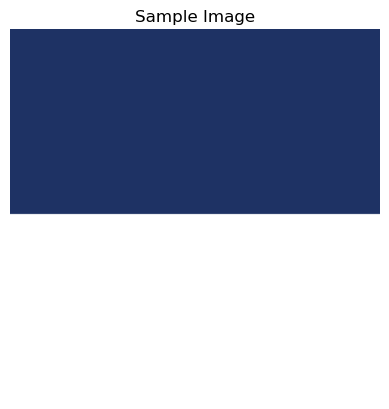

In [3]:
# Create a sample image for testing
def create_sample_image():
    """Create a simple sample image with known colors."""
    # Create 224x224 image with color blocks
    img = np.zeros((224, 224, 3), dtype=np.uint8)
    
    # Navy blue (top half)
    img[:112, :, :] = [30, 50, 100]  # RGB
    
    # White (bottom half)
    img[112:, :, :] = [255, 255, 255]
    
    return img

sample_img = create_sample_image()
plt.imshow(sample_img)
plt.title("Sample Image")
plt.axis('off')
plt.show()

In [4]:
# Extract colors from sample
colors = color_extractor.extract(sample_img)

print("Extracted Colors:")
for i, color in enumerate(colors):
    print(f"  {i+1}. {color.name}")
    print(f"     RGB: {color.rgb}")
    print(f"     LAB: {color.lab}")
    print(f"     Percentage: {color.percentage:.1%}")
    print(f"     Hex: {color.to_hex()}")
    print()

Extracted Colors:
  1. navy
     RGB: (29, 50, 100)
     LAB: (21.960784912109375, 10.0, -32.0)
     Percentage: 50.0%
     Hex: #1d3264

  2. white
     RGB: (255, 255, 255)
     LAB: (100.0, 0.0, 0.0)
     Percentage: 50.0%
     Hex: #ffffff



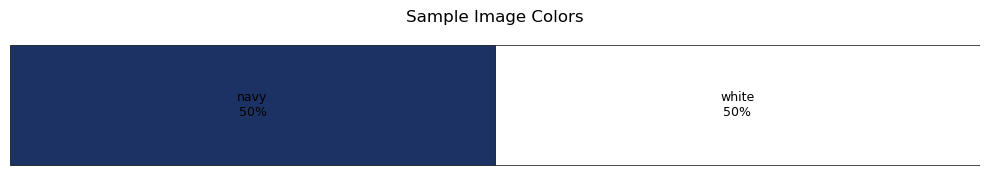

In [5]:
# Visualize extracted colors
def visualize_colors(colors, title="Dominant Colors"):
    """Visualize extracted colors as a bar chart."""
    fig, ax = plt.subplots(figsize=(10, 2))
    
    left = 0
    for color in colors:
        width = color.percentage
        ax.barh(0, width, left=left, color=np.array(color.rgb)/255, 
                edgecolor='black', linewidth=0.5)
        
        # Add label if wide enough
        if width > 0.1:
            ax.text(left + width/2, 0, f"{color.name}\n{color.percentage:.0%}", 
                   ha='center', va='center', fontsize=9)
        left += width
    
    ax.set_xlim(0, 1)
    ax.set_ylim(-0.5, 0.5)
    ax.set_title(title)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

visualize_colors(colors, "Sample Image Colors")

## 2.2 Color Harmony Analysis

We analyze color harmony to understand which colors work well together.

In [6]:
# Initialize harmony analyzer
harmony_analyzer = ColorHarmonyAnalyzer()

# Create test color sets
from src.attributes.color_extractor import DominantColor

# Blue item
blue_colors = [
    DominantColor(rgb=(30, 50, 150), lab=(25, 30, -60), percentage=0.8, name="blue")
]

# Orange item (complementary to blue)
orange_colors = [
    DominantColor(rgb=(255, 140, 0), lab=(70, 30, 70), percentage=0.8, name="orange")
]

# Navy item (analogous to blue)
navy_colors = [
    DominantColor(rgb=(0, 0, 80), lab=(10, 20, -40), percentage=0.8, name="navy")
]

# Gray item (neutral)
gray_colors = [
    DominantColor(rgb=(128, 128, 128), lab=(54, 0, 0), percentage=0.8, name="gray")
]

In [7]:
# Analyze different color pairings
def analyze_pair(colors1, colors2, name1="Item 1", name2="Item 2"):
    harmony = harmony_analyzer.analyze_harmony(colors1, colors2)
    print(f"{name1} + {name2}:")
    print(f"  Harmony Type: {harmony['harmony_type']}")
    print(f"  Score: {harmony['score']:.2f}")
    print(f"  Hue Difference: {harmony['hue_difference']:.1f}")
    print()
    return harmony

# Test pairings
analyze_pair(blue_colors, orange_colors, "Blue top", "Orange pants")  # Complementary
analyze_pair(blue_colors, navy_colors, "Blue top", "Navy pants")  # Analogous
analyze_pair(blue_colors, gray_colors, "Blue top", "Gray pants")  # Neutral

Blue top + Orange pants:
  Harmony Type: complementary
  Score: 0.90
  Hue Difference: 162.9

Blue top + Navy pants:
  Harmony Type: analogous
  Score: 0.85
  Hue Difference: 10.0

Blue top + Gray pants:
  Harmony Type: neutral-pairing
  Score: 0.95
  Hue Difference: 130.0



{'harmony_type': 'neutral-pairing',
 'score': 0.9500000000000001,
 'hue_difference': 129.99999999999997,
 'colors': {'item1': {'name': 'blue', 'rgb': (30, 50, 150)},
  'item2': {'name': 'gray', 'rgb': (128, 128, 128)}}}

## 2.3 Color Feature Vector

For the compatibility model, we need a fixed-size feature vector from colors.

In [8]:
# Get color feature vector
color_vector = color_extractor.get_color_vector(sample_img)

print(f"Color vector shape: {color_vector.shape}")
print(f"Color vector (LAB values for top {color_extractor.n_colors} colors):")
for i in range(color_extractor.n_colors):
    lab = color_vector[i*3:(i+1)*3]
    print(f"  Color {i+1}: L={lab[0]:.1f}, A={lab[1]:.1f}, B={lab[2]:.1f}")

Color vector shape: (15,)
Color vector (LAB values for top 5 colors):
  Color 1: L=22.0, A=10.0, B=-32.0
  Color 2: L=100.0, A=0.0, B=0.0
  Color 3: L=0.0, A=0.0, B=0.0
  Color 4: L=0.0, A=0.0, B=0.0
  Color 5: L=0.0, A=0.0, B=0.0


## 2.4 Combined Attribute Pipeline

Create the full attribute extraction pipeline combining classification and color extraction.

In [9]:
from src.attributes.pipeline import AttributePipeline, GarmentAttributes

# Load classifier (if trained)
model_path = Path('../models/garment_classifier.pth')

if model_path.exists():
    classifier = GarmentClassifier.load(model_path)
    print("Loaded trained classifier")
else:
    # Use pretrained (untrained on fashion)
    classifier = GarmentClassifier(
        backbone="efficientnet_b0",
        pretrained=True
    )
    classifier.to(get_device())
    classifier.device = get_device()
    print("Using pretrained backbone (not fine-tuned)")

# Create pipeline
pipeline = AttributePipeline(
    classifier=classifier,
    color_extractor=color_extractor
)

print("Pipeline ready!")

Loaded trained classifier
Pipeline ready!


In [10]:
# Test the full pipeline
attrs = pipeline.process(sample_img, item_id="test_item")

print("Extracted Attributes:")
print(f"  Item ID: {attrs.item_id}")
print(f"  Category: {attrs.category} ({attrs.category_confidence:.1%})")
print(f"  Dominant Colors: {[c.name for c in attrs.dominant_colors]}")
print(f"  Visual Embedding Shape: {attrs.visual_embedding.shape}")
print(f"  Color Vector Shape: {attrs.color_vector.shape}")

Extracted Attributes:
  Item ID: test_item
  Category: accessories (28.1%)
  Dominant Colors: ['navy', 'white']
  Visual Embedding Shape: (1280,)
  Color Vector Shape: (15,)


## 2.5 Test on Real Images (Optional)

If you have sample images, test the pipeline on them.

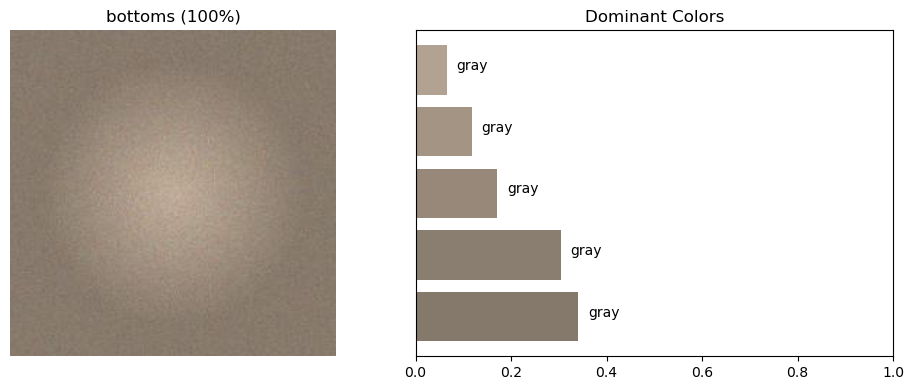

In [11]:
# Test on real images if available
sample_dir = Path('../data/samples')

if sample_dir.exists():
    for img_path in sample_dir.glob('*.jpg'):
        # Process
        attrs = pipeline.process(str(img_path))
        
        # Display
        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        
        # Image
        img = Image.open(img_path)
        axes[0].imshow(img)
        axes[0].set_title(f"{attrs.category} ({attrs.category_confidence:.0%})")
        axes[0].axis('off')
        
        # Colors
        for i, color in enumerate(attrs.dominant_colors):
            axes[1].barh(i, color.percentage, color=np.array(color.rgb)/255)
            axes[1].text(color.percentage + 0.02, i, color.name)
        
        axes[1].set_xlim(0, 1)
        axes[1].set_title('Dominant Colors')
        axes[1].set_yticks([])
        
        plt.tight_layout()
        plt.show()
        break  # Show just one
else:
    print(f"No sample images found in {sample_dir}")
    print("Add some .jpg images there to test the pipeline.")

## Summary

In this notebook we:
1. Implemented color extraction using k-means clustering in LAB color space
2. Created color harmony analysis for understanding color relationships
3. Built a combined attribute pipeline for processing garment images
4. The pipeline extracts both visual features and color features

**Next Step:** Run notebook 03 for Compatibility Modeling